In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
import os

# Add the experiments/analysis directory to path
sys.path.insert(0, os.path.abspath('../../../../experiments/analysis'))

# Now import
from model_comparison_plots import load_all_results, aggregate_by_county, plot_paired_scatter, plot_bland_altman, plot_raincloud, create_all_plots

In [168]:
def aggregate_by_county(df: pd.DataFrame, metric: str = 'mae') -> pd.DataFrame:
    """
    Aggregate results to county level by computing mean across repetitions and folds.

    Parameters
    ----------
    df : pd.DataFrame
        Raw results dataframe from load_all_results()
    metric : str, default='mae'
        Performance metric to aggregate (e.g., 'mae', 'rmse', 'r2')

    Returns
    -------
    pd.DataFrame
        Aggregated dataframe with columns: fips, model, {metric}_mean
    """
    # Group by county (fips) and model, compute mean of the metric
    # aggregate by metric and train_size
    # agg_dic = {metric: ['mean', 'std'], 'train_size': 'mean' }
    agg_df = df.groupby(['fips', 'model']).agg(
        metric_mean=(metric, 'mean'),
        metric_std=(metric, 'std'),
        train_size_mean=('train_size', 'mean'),
        n_features=('n_features', 'mean')
    ).reset_index()
    agg_df.columns = ['fips', 'model', f'{metric}_mean', f'{metric}_std', 'train_size_mean', 'n_features']

    # # Pivot to have tabpfn and xgboost as separate columns for easier comparison
    pivot_df = agg_df.pivot(index='fips', columns='model', values=[f'{metric}_mean', f'{metric}_std']).reset_index()
    
    # flatten multi-level columns
    pivot_df.columns = [
        "_".join(col).strip("_") if isinstance(col, tuple) else col
        for col in pivot_df.columns
    ]

    train_sizes = agg_df[['fips', 'train_size_mean', 'n_features']].drop_duplicates()

    pivot_df = pd.merge(pivot_df, train_sizes, on='fips', how='left')

    return pivot_df


In [3]:
df = load_all_results('../')

Loaded 50 files with 5000 total rows


In [173]:
df.head()

,experiment_name,experiment_description,fips,bin_name,repetition,fold,model,train_size,test_size,n_features,...,hyperparam_max_depth,hyperparam_learning_rate,hyperparam_n_estimators,hyperparam_subsample,hyperparam_colsample_bytree,hyperparam_min_child_weight,hyperparam_reg_alpha,hyperparam_reg_lambda,hyperparam_gamma,tune_time
0,with_preprocessing,"Property chars with winsorization, log transfo...",28129,small,0,0,tabpfn,36,10,48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,with_preprocessing,"Property chars with winsorization, log transfo...",28129,small,0,0,xgboost,36,10,48,...,4.0,0.229996,50.0,0.758795,0.713568,5.0,0.059890,0.348898,0.807142,5.813081
2,with_preprocessing,"Property chars with winsorization, log transfo...",28129,small,0,1,tabpfn,37,9,48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,with_preprocessing,"Property chars with winsorization, log transfo...",28129,small,0,1,xgboost,37,9,48,...,5.0,0.010336,350.0,0.756950,0.726676,5.0,0.010267,0.538254,0.031245,6.059726
4,with_preprocessing,"Property chars with winsorization, log transfo...",28129,small,0,2,tabpfn,37,9,48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [169]:
pivot_df = aggregate_by_county(df, 'mae')

In [170]:
pivot_df.head()

,fips,mae_mean_tabpfn,mae_mean_xgboost,mae_std_tabpfn,mae_std_xgboost,train_size_mean,n_features
0,1011,74398.807768,79532.554298,23212.254934,26772.868759,68.8,39.0
1,1041,74441.839590,90190.305156,37286.408419,47966.100017,13.6,21.0
2,1065,58606.734025,62191.206582,17343.906581,14856.922472,59.2,42.0
3,1075,42418.242935,46400.313029,15791.472572,17557.280496,27.2,23.0
4,2016,79564.981076,80008.503100,19487.674785,21042.793686,27.2,6.0


In [130]:
pivot_df[pivot_df['mae_mean_xgboost'] < pivot_df['mae_mean_tabpfn']]['fips'].values

array([ 2232, 16033, 21237, 25007, 28005, 28009, 28037, 28053, 28065,
       28125, 31009])

In [131]:
pivot_df[pivot_df['mae_std_xgboost'] < pivot_df['mae_std_tabpfn']]['fips'].values

array([ 1065,  2100,  2232,  8033,  8061, 13101, 13307, 16033, 25007,
       28005, 28037, 28061, 28131, 29199, 30069, 30075, 31015])

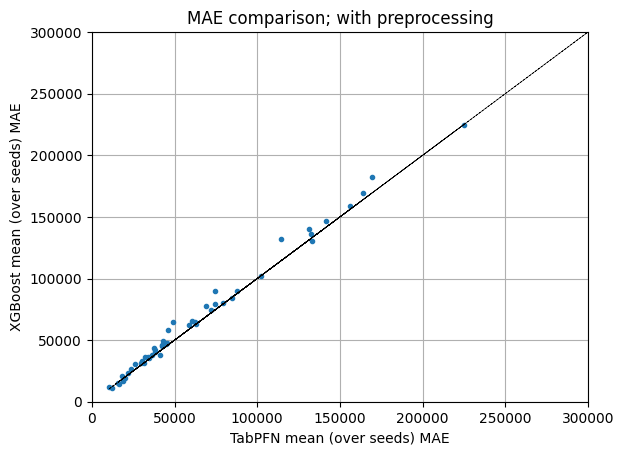

In [135]:
plt.plot(pivot_df['mae_mean_tabpfn'], pivot_df['mae_mean_xgboost'], 'o', markersize=3)
plt.plot(pivot_df['mae_mean_tabpfn'], pivot_df['mae_mean_tabpfn'], 'k--', linewidth=0.5)
plt.xlim(0, 300000)
plt.ylim(0, 300000)
plt.xlabel('TabPFN mean (over seeds) MAE')
plt.ylabel('XGBoost mean (over seeds) MAE')
plt.title('MAE comparison; with preprocessing')
plt.grid()
plt.show()

In [35]:
pivot_df['tabpfn'].describe()

count        50.000000
mean      77891.814772
std      109770.154435
min       10210.782643
25%       31622.569139
50%       45017.362393
75%       83294.740933
max      760828.223489
Name: tabpfn, dtype: float64

In [36]:
pivot_df['xgboost'].describe()

count        50.000000
mean      80961.002666
std      107258.822839
min       11231.017217
25%       33434.419009
50%       48456.294921
75%       88140.046358
max      739895.825057
Name: xgboost, dtype: float64

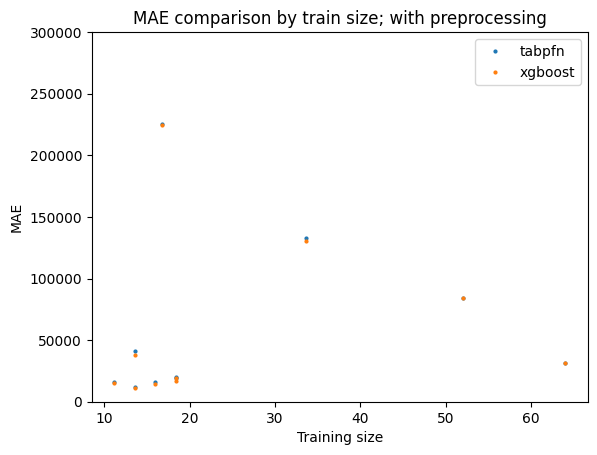

In [162]:
# plt.plot(pivot_df['train_size_mean'], pivot_df['mae_mean_tabpfn'], 'o', markersize=2, label='tabpfn')
# plt.plot(pivot_df['train_size_mean'], pivot_df['mae_mean_xgboost'], 'o', markersize=2, label='xgboost')

temp_df = pivot_df[pivot_df['mae_mean_tabpfn'] > pivot_df['mae_mean_xgboost']]
plt.plot(temp_df['train_size_mean'], temp_df['mae_mean_tabpfn'], 'o', markersize=2, label='tabpfn')
plt.plot(temp_df['train_size_mean'], temp_df['mae_mean_xgboost'], 'o', markersize=2, label='xgboost')
plt.ylim(0, 300000)
plt.legend()
plt.xlabel('Training size')
plt.ylabel('MAE')
plt.title('MAE comparison by train size; with preprocessing')
plt.show()

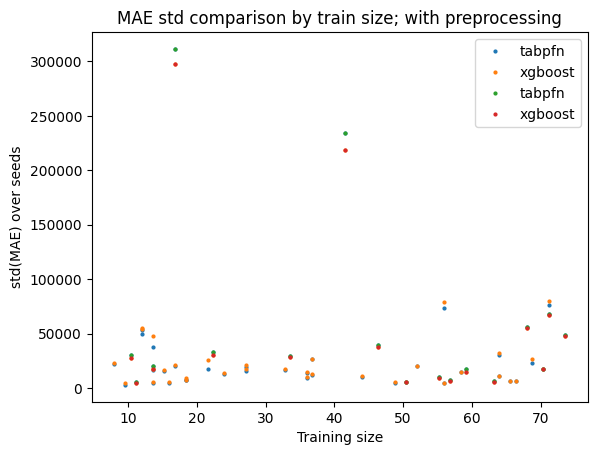

In [167]:
plt.plot(pivot_df['train_size_mean'], pivot_df['mae_std_tabpfn'], 'o', markersize=2, label='tabpfn')
plt.plot(pivot_df['train_size_mean'], pivot_df['mae_std_xgboost'], 'o', markersize=2, label='xgboost')

# temp_df = pivot_df[pivot_df['mae_mean_tabpfn'] > pivot_df['mae_mean_xgboost']]
temp_df = pivot_df[pivot_df['mae_std_tabpfn'] > pivot_df['mae_std_xgboost']]
plt.plot(temp_df['train_size_mean'], temp_df['mae_std_tabpfn'], 'o', markersize=2, label='tabpfn')
plt.plot(temp_df['train_size_mean'], temp_df['mae_std_xgboost'], 'o', markersize=2, label='xgboost')
# plt.ylim(0, 300000)
plt.legend()
plt.xlabel('Training size')
plt.ylabel('std(MAE) over seeds')
plt.title('MAE std comparison by train size; with preprocessing')
plt.show()

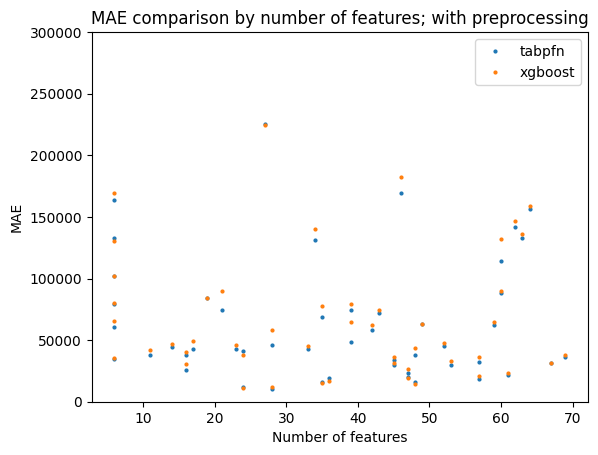

In [172]:
plt.plot(pivot_df['n_features'], pivot_df['mae_mean_tabpfn'], 'o', markersize=2, label='tabpfn')
plt.plot(pivot_df['n_features'], pivot_df['mae_mean_xgboost'], 'o', markersize=2, label='xgboost')

temp_df = pivot_df[pivot_df['mae_mean_tabpfn'] > pivot_df['mae_mean_xgboost']]
# plt.plot(temp_df['n_features'], temp_df['mae_mean_tabpfn'], 'o', markersize=2, label='tabpfn')
# plt.plot(temp_df['n_features'], temp_df['mae_mean_xgboost'], 'o', markersize=2, label='xgboost')
plt.ylim(0, 300000)
plt.legend()
plt.xlabel('Number of features')
plt.ylabel('MAE')
plt.title('MAE comparison by number of features; with preprocessing')
plt.show()

## analysis between runs

In [39]:
import numpy as np

In [136]:
pivot_df['fips'].values

array([ 1011,  1041,  1065,  1075,  2016,  2100,  2185,  2232,  2275,
        8033,  8061, 13007, 13101, 13265, 13307, 16033, 17069, 21189,
       21237, 25007, 28005, 28009, 28021, 28037, 28041, 28053, 28061,
       28065, 28111, 28117, 28125, 28129, 28131, 28139, 28163, 29017,
       29083, 29085, 29149, 29199, 30039, 30045, 30051, 30055, 30069,
       30075, 31009, 31015, 31085, 31091])

In [137]:
with_pre_all = pivot_df['fips'].values

# the below are just where tabpfn was worse than xgboost
with_pre = np.array([ 2232, 16033, 21237, 25007, 28005, 28009, 28037, 28053, 28065,
       28125, 31009])

no_pre = np.array([ 1041,  2185,  8061, 25007, 28009, 28037, 28125, 28163, 29149,
       29199, 30069, 31085])

calib_top_errors = np.array([28021, 30069, 28163,  2275, 28139, 16033, 28037, 28005, 29149,
        1041,  2185, 28009, 28053,  1075, 30051])

In [69]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Your list of county FIPS ----
fips_list = ["06075", "17031", "36061"]  # example: SF county, Cook, Manhattan

# ---- 2. Load U.S. county shapefile ----
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)

In [145]:
# # Keep only the lower-48 states
lower48_states = {
    '01','04','05','06','08','09','10','11','12','13','16','17','18','19','20',
    '21','22','23','24','25','26','27','28','29','30','31','32','33','34','35','36',
    '37','38','39','40','41','42','44','45','46','47','48','49','50','51','53','54',
    '55','56'
}
lower48 = counties[counties["STATEFP"].isin(lower48_states)]

# Select your counties
with_pre = counties[counties["GEOID"].isin(with_pre.astype(str))]

# Reproject to US Albers (fixes distortion)
lower48_aea = lower48.to_crs("EPSG:5070")
with_pre_aea = with_pre.to_crs("EPSG:5070")

with_pre_all = counties[counties["GEOID"].isin(with_pre_all.astype(str))]
with_pre_all_aea = with_pre_all.to_crs("EPSG:5070")

no_pre = counties[counties["GEOID"].isin(no_pre.astype(str))]
no_pre_aea = no_pre.to_crs("EPSG:5070")

calib_top_errors = counties[counties["GEOID"].isin(calib_top_errors.astype(str))]
calib_top_errors_aea = calib_top_errors.to_crs("EPSG:5070")

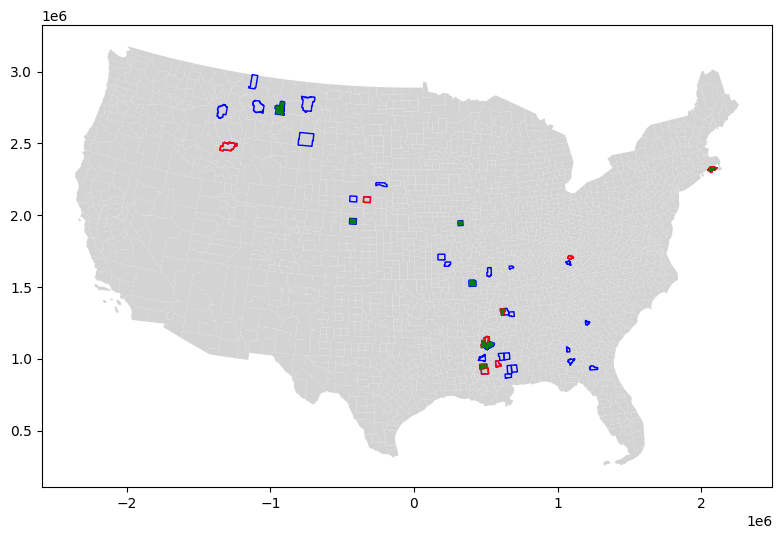

In [150]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
lower48_aea.plot(ax=ax, color="lightgrey", linewidth=0.1)
with_pre_all_aea.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=1, label='all')
with_pre_aea.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1, label='worse than xgboost')
no_pre_aea.plot(ax=ax, edgecolor="none", facecolor="green", linewidth=1, label='no preprocessing')
# calib_top_errors_aea.plot(ax=ax, facecolor="none", hatch="///", linewidth=1, label='calib top errors')
# ax.set_axis_off()
plt.show()

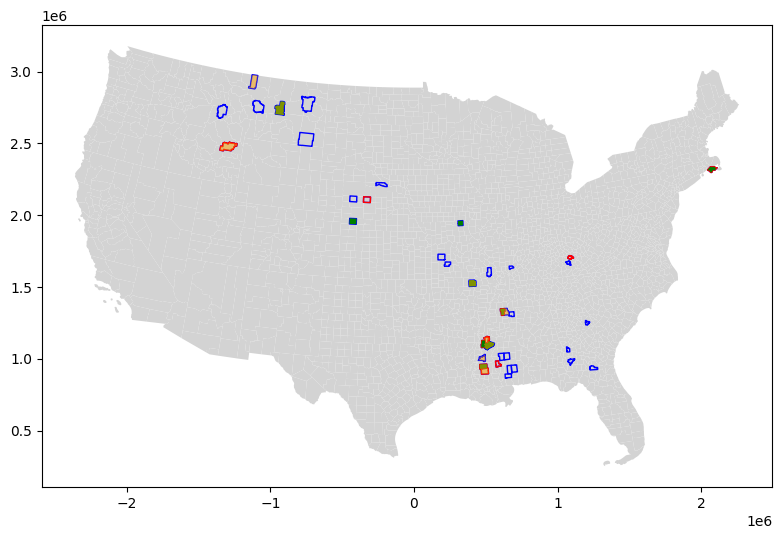

In [155]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
lower48_aea.plot(ax=ax, color="lightgrey", linewidth=0.1)
with_pre_all_aea.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=1, label='all')
with_pre_aea.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1, label='worse than xgboost')
no_pre_aea.plot(ax=ax, edgecolor="none", facecolor="green", linewidth=1, label='no preprocessing')
calib_top_errors_aea.plot(ax=ax, edgecolor="none", facecolor="orange", alpha=0.5, linewidth=1, label='calib top errors')
# ax.set_axis_off()
plt.show()